# Final Project

## Question: How... ?

In [20]:
import mesa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from collections import deque

import networkx as nx

# Simulating a simple agent

Each agent has the following attributes:
* age_group: GenZ, Millenial, Boomer. Different age groups behave differently on the Internet.
* english_proficiency: Between 1 and 3. 1: Low, 2: Medium, 3: High. Describes how well the user speaks and understands English.
* topic: Gaming, Tech, Fashion, Nature. The preferred topic of the user.
* platforms: Instagram, TikTok, Reddit. The list of platforms used. A user can have one platform or use multiple platforms (cross-platform)

In [39]:
age_groups: list[str] = ["GenZ", "Millenial", "Boomer"]
topics: list[str] = ["Gaming", "Tech", "Fashion", "Nature"]
platforms: list[str] = ["Instagram", "TikTok", "Reddit"]

In [56]:
class PlayerAgent(mesa.Agent):
    def __init__(self, model:mesa.Model):
        super().__init__(model)

        self.age_group: int = self.get_random_age_group()
        self.english_proficiency: int = self.get_random_english_proficiency()
        self.main_topic: str = self.get_random_main_topic()
        self.platforms: list[str] = self.get_random_platforms()

        self.adopted = False # Whether the user adopted the english word or not

    def get_random_age_group(self) -> int:
        return random.choice(age_groups)

    def get_random_english_proficiency(self) -> int:
        return random.randint(1, 3)

    def get_random_main_topic(self) -> str:
        return random.choice(topics)

    def get_random_platforms(self) -> list[str]:
        random_platforms: list[str] = []

        for platform in platforms:
            if random.random() < 0.33:
                random_platforms.append(platform)

        # If player still has no platform, force a random one
        if len(random_platforms) == 0:
            random_platforms.append(random.choice(platforms))
        
        return random_platforms

    def print_description(self):
        """Prints the descirption of the player"""
        print(f'Player {self.unique_id} :')
        print(f'Age Group : {self.age_group}')
        print(f'English proficiency : {self.english_proficiency}')
        print(f'Main topic : {self.main_topic}')
        print("Platforms : ", end="")
        for i in range(len(self.platforms)):
            if i != 0:
                print(", ", end="")
            print(self.platforms[i], end="")

In [57]:
class SimpleGame(mesa.Model):
    def __init__(self, players_count: int):
        super().__init__()

        self.players_count: int = players_count
        self.player: PlayerAgent = PlayerAgent(self)

In [68]:
game: SimpleGame = SimpleGame(10)
game.player.print_description()

Player 1 :
Age Group : GenZ
English proficiency : 3
Main topic : Fashion
Platforms : Instagram

# Creating Networks of social media users

In [89]:
class Network(mesa.Model):
    def __init__(self, rounds_count: int, players_count: int):
        super().__init__()

        self.network = nx.Graph()
        self.rounds_count: int = rounds_count
        self.players_count: int = players_count
        self.players: list[PlayerAgent] = []
        self.adopted_players : list[PlayerAgent] = []

        self.connect_crossplatform_threshold: float = 0.2
        self.initial_adopters_count: int = 5

        self.create_players()
        self.connect_cross_platform_users()
        self.pick_initial_adopters()

        self.datacollector = mesa.DataCollector(
            {"Adoption Rate" : self.adoption_rate}
        )

    def create_players(self):
        """Creates all player agents and connects them in a network of social media users."""
        for _ in range(self.players_count):
            new_player: PlayerAgent = PlayerAgent(self)
            self.players.append(new_player)
            self.network.add_node(new_player)

    def connect_cross_platform_users(self):
        """Tries to connect users between each other if they share common platforms."""
        for player1 in self.players:
            for player2 in self.players:
                if player1 == player2:
                    continue

                shared_platforms: set[str] = set(player1.platforms) & set(player2.platforms)

                if len(shared_platforms) > 0 and random.random() < self.connect_crossplatform_threshold:
                    self.network.add_edge(player1, player2)

    def pick_initial_adopters(self):
        """Pick a few inital adopters that already know English words. Behave as influencers to influence other users to also use their words."""
        initial_adopters: list[PlayerAgent] = random.sample(self.players, self.initial_adopters_count)
        for player in initial_adopters:
            player.adopted = True
            self.adopted_players.append(player)

    def play_game(self):
        for i in range(self.rounds_count):
            print(f'Round {i + 1} :')
            self.play_round()
            print(f'Got adoption rate: {self.adoption_rate()} %')
            self.datacollector.collect(self)

    def play_round(self):
        new_adopted_players: list[PlayerAgent] = []

        for player in self.players:
            neighbors: list[PlayerAgent] = list(self.network.neighbors(player))

            # Count the number of adopted neighbors
            adopted_neighbors: int = 0
            for neighbor in neighbors:
                if neighbor.adopted:
                    adopted_neighbors += 1
            
            # Compute adoption probability based on agent properties
            adoption_probability: float = 0.05

            if len(neighbors) > 0:
                adopted_fraction: float = adopted_neighbors / len(neighbors)
                adoption_probability += 0.5 * adopted_fraction

            adoption_probability += 0.02 * player.english_proficiency
            
            if player.age_group == "GenZ":
                adoption_probability += 0.15
            elif player.age_group == "Millenial":
                adoption_probability += 0.05

            if adoption_probability >= 1:
                adoption_probability = 1
            
            if not player.adopted:
                if random.random() < adoption_probability:
                    print(f'Agent {player.unique_id} adopted the English word ! (P = {adoption_probability} %)')
                    new_adopted_players.append(player)
                else:
                    print(f'Agent {player.unique_id} did not adopt the english word ! (P = {adoption_probability} %)')

        for adopted_player in new_adopted_players:
            adopted_player.adopted = True
            self.adopted_players.append(adopted_player)
    
    def adoption_rate(self) -> float:
        """Function for data collection. Returns the proportion of adopted players in the network."""
        return len(self.adopted_players) / self.players_count

In [90]:
def plot_adoption_rate(data: pd.DataFrame):
    adoption_rate = data["Adoption Rate"]
    rounds = np.arange(1, len(adoption_rate) + 1)

    plt.plot(rounds, adoption_rate)
    plt.title("Evolution of adoption rate over rounds")
    plt.xlabel("Rounds")
    plt.ylabel("Adoption rate (%)")
    plt.grid(True, alpha=0.3)

    plt.show()

Round 1 :
Agent 1 did not adopt the english word ! (P = 0.16 %)
Agent 2 did not adopt the english word ! (P = 0.26 %)
Agent 3 did not adopt the english word ! (P = 0.09 %)
Agent 4 did not adopt the english word ! (P = 0.07337837837837838 %)
Agent 5 did not adopt the english word ! (P = 0.1666225165562914 %)
Agent 6 did not adopt the english word ! (P = 0.14 %)
Agent 7 did not adopt the english word ! (P = 0.12303030303030303 %)
Agent 8 adopted the English word ! (P = 0.09657894736842106 %)
Agent 9 did not adopt the english word ! (P = 0.11609756097560975 %)
Agent 10 did not adopt the english word ! (P = 0.16341296928327648 %)
Agent 11 did not adopt the english word ! (P = 0.07333333333333333 %)
Agent 12 did not adopt the english word ! (P = 0.24176678445229682 %)
Agent 13 did not adopt the english word ! (P = 0.2229585798816568 %)
Agent 14 did not adopt the english word ! (P = 0.09185873605947956 %)
Agent 15 adopted the English word ! (P = 0.26694444444444443 %)
Agent 16 did not adopt 

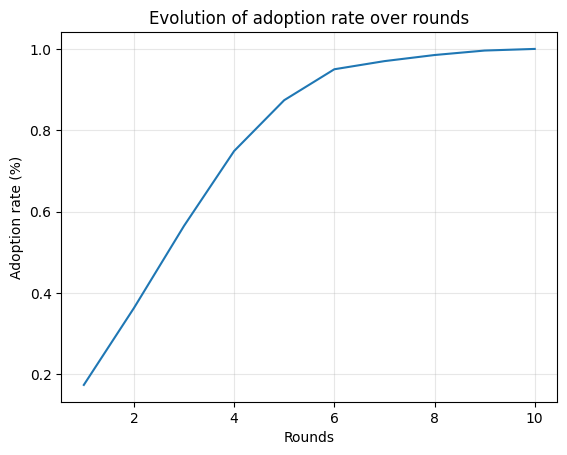

In [95]:
network = Network(rounds_count=10, players_count=1000)
network.play_game()
for player in network.players:
    player.print_description()
    print()

data = network.datacollector.get_model_vars_dataframe()
plot_adoption_rate(data)